### 决策树过拟合问题

In [246]:
import numpy as np
import matplotlib.pyplot as plt

In [247]:
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data[:, 0:2]
y = iris.target

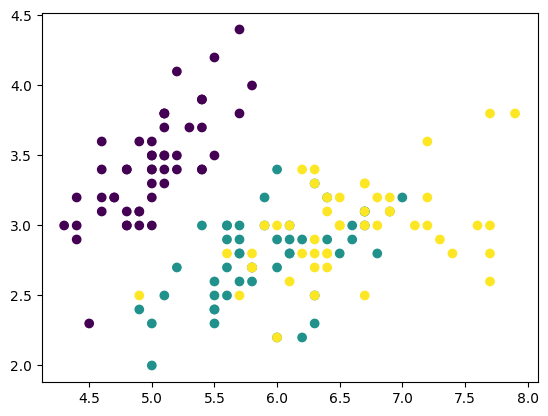

In [248]:
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()

In [249]:
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier()
clf.fit(X, y);

In [250]:
def decision_boundary_plot(X, y, clf):  # 获取两个特征的最小值和最大值，并向外扩展 1 个单位，作为绘图范围
    axis_x1_min, axis_x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    axis_x2_min, axis_x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    x1, x2 = np.meshgrid(    # 在两个特征范围内生成密集的二维网格点。步长越小，绘制出的决策边界越平滑
        np.arange(axis_x1_min, axis_x1_max, 0.01),
        np.arange(axis_x2_min, axis_x2_max, 0.01))
    # 将二维网格展开并组合成模型需要的二维特征数据，然后预测每一个网格点所属的类别
    z = clf.predict(np.c_[x1.ravel(), x2.ravel()])
    # 将预测结果恢复成与网格相同的形状，方便后续绘图
    z = z.reshape(x1.shape)

    from matplotlib.colors import ListedColormap
    custom_cmap = ListedColormap(['#F5B9EF', '#BBFFBB', '#F9F9CB'])  # 自定义三种类别对应的背景颜色

    plt.contourf(x1, x2, z, cmap=custom_cmap)  # 根据模型预测结果绘制不同类别的决策区域
    plt.scatter(X[:, 0], X[:, 1], c=y)  # 绘制原始样本点，颜色由真实类别 y 决定
    plt.show()

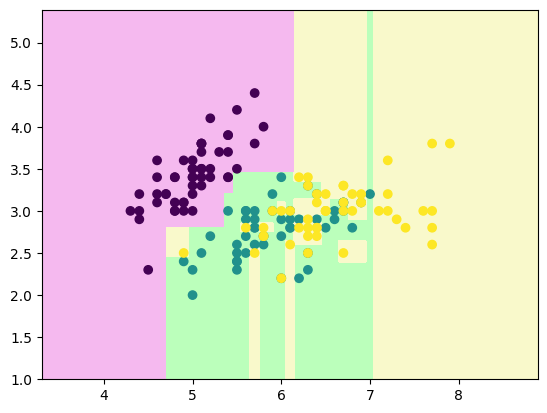

In [251]:
decision_boundary_plot(X, y, clf)

[Text(0.36890243902439024, 0.9615384615384616, 'x[0] <= 5.45\ngini = 0.667\nsamples = 150\nvalue = [50, 50, 50]'),
 Text(0.0975609756097561, 0.8846153846153846, 'x[1] <= 2.8\ngini = 0.237\nsamples = 52\nvalue = [45, 6, 1]'),
 Text(0.23323170731707316, 0.9230769230769231, 'True  '),
 Text(0.04878048780487805, 0.8076923076923077, 'x[0] <= 4.7\ngini = 0.449\nsamples = 7\nvalue = [1, 5, 1]'),
 Text(0.024390243902439025, 0.7307692307692307, 'gini = 0.0\nsamples = 1\nvalue = [1, 0, 0]'),
 Text(0.07317073170731707, 0.7307692307692307, 'x[0] <= 4.95\ngini = 0.278\nsamples = 6\nvalue = [0, 5, 1]'),
 Text(0.04878048780487805, 0.6538461538461539, 'x[1] <= 2.45\ngini = 0.5\nsamples = 2\nvalue = [0, 1, 1]'),
 Text(0.024390243902439025, 0.5769230769230769, 'gini = 0.0\nsamples = 1\nvalue = [0, 1, 0]'),
 Text(0.07317073170731707, 0.5769230769230769, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.0975609756097561, 0.6538461538461539, 'gini = 0.0\nsamples = 4\nvalue = [0, 4, 0]'),
 Text(0.14634

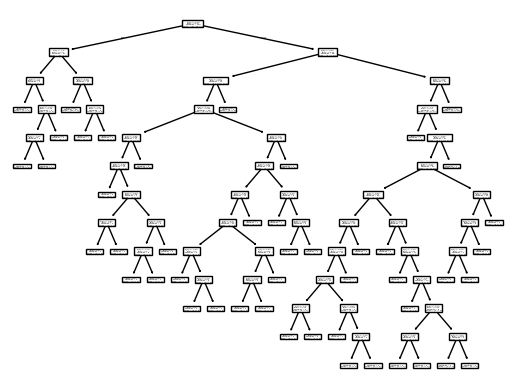

In [252]:
from sklearn.tree import plot_tree
plot_tree(clf)

### 决策树剪枝（预剪枝）

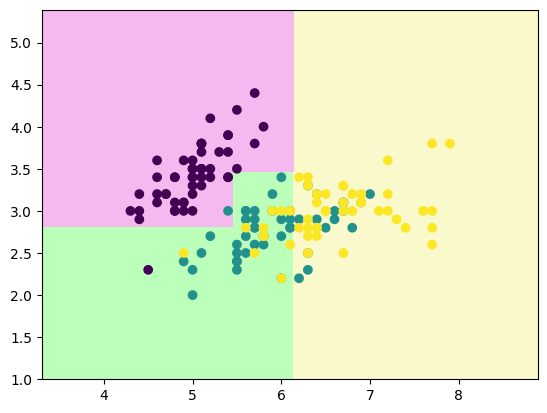

[Text(0.5, 0.875, 'x[0] <= 5.45\ngini = 0.667\nsamples = 150\nvalue = [50, 50, 50]'),
 Text(0.25, 0.625, 'x[1] <= 2.8\ngini = 0.237\nsamples = 52\nvalue = [45, 6, 1]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'gini = 0.449\nsamples = 7\nvalue = [1, 5, 1]'),
 Text(0.375, 0.375, 'gini = 0.043\nsamples = 45\nvalue = [44, 1, 0]'),
 Text(0.75, 0.625, 'x[0] <= 6.15\ngini = 0.546\nsamples = 98\nvalue = [5, 44, 49]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[1] <= 3.45\ngini = 0.508\nsamples = 43\nvalue = [5.0, 28.0, 10.0]'),
 Text(0.5, 0.125, 'gini = 0.388\nsamples = 38\nvalue = [0, 28, 10]'),
 Text(0.75, 0.125, 'gini = 0.0\nsamples = 5\nvalue = [5, 0, 0]'),
 Text(0.875, 0.375, 'gini = 0.413\nsamples = 55\nvalue = [0, 16, 39]')]

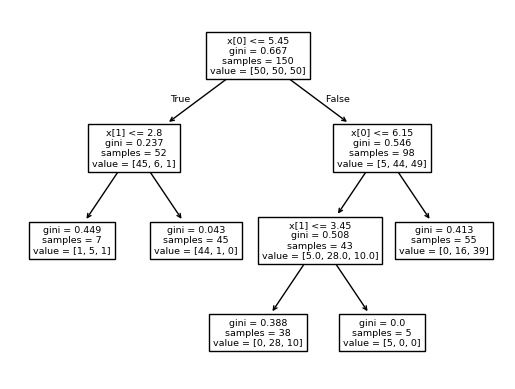

In [253]:
clf = DecisionTreeClassifier(max_depth=5, min_samples_split=10, min_samples_leaf=5, max_leaf_nodes=5, min_weight_fraction_leaf=0.033)
clf.fit(X, y)
decision_boundary_plot(X, y, clf)
plot_tree(clf)

### 决策树剪枝（后剪枝）

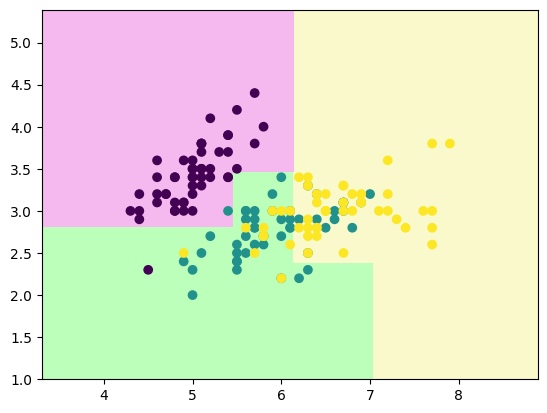

[Text(0.4090909090909091, 0.9, 'x[0] <= 5.45\ngini = 0.667\nsamples = 150\nvalue = [50, 50, 50]'),
 Text(0.18181818181818182, 0.7, 'x[1] <= 2.8\ngini = 0.237\nsamples = 52\nvalue = [45, 6, 1]'),
 Text(0.29545454545454547, 0.8, 'True  '),
 Text(0.09090909090909091, 0.5, 'gini = 0.449\nsamples = 7\nvalue = [1, 5, 1]'),
 Text(0.2727272727272727, 0.5, 'gini = 0.043\nsamples = 45\nvalue = [44, 1, 0]'),
 Text(0.6363636363636364, 0.7, 'x[0] <= 6.15\ngini = 0.546\nsamples = 98\nvalue = [5, 44, 49]'),
 Text(0.5227272727272727, 0.8, '  False'),
 Text(0.45454545454545453, 0.5, 'x[1] <= 3.45\ngini = 0.508\nsamples = 43\nvalue = [5.0, 28.0, 10.0]'),
 Text(0.36363636363636365, 0.3, 'gini = 0.388\nsamples = 38\nvalue = [0, 28, 10]'),
 Text(0.5454545454545454, 0.3, 'gini = 0.0\nsamples = 5\nvalue = [5, 0, 0]'),
 Text(0.8181818181818182, 0.5, 'x[0] <= 7.05\ngini = 0.413\nsamples = 55\nvalue = [0, 16, 39]'),
 Text(0.7272727272727273, 0.3, 'x[1] <= 2.4\ngini = 0.467\nsamples = 43\nvalue = [0, 16, 27]'),


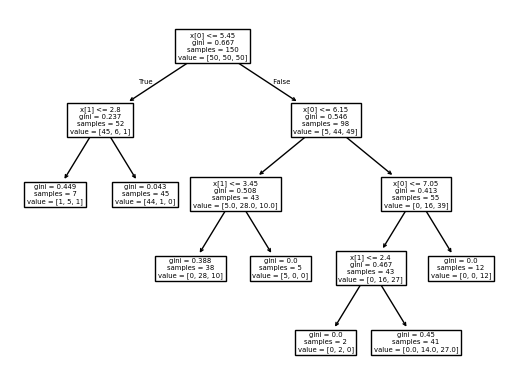

In [254]:
clf = DecisionTreeClassifier(ccp_alpha=0.01)
clf.fit(X, y)
decision_boundary_plot(X, y, clf)
plot_tree(clf)

### 决策树剪枝（后剪枝：寻找最佳ccp_alpha）

In [255]:
path = clf.cost_complexity_pruning_path(X,y)
ccp_alphas = path.ccp_alphas
ccp_alphas

array([0.        , 0.        , 0.00044444, 0.00111111, 0.00133333,
       0.00222222, 0.00266667, 0.00345455, 0.00392157, 0.004     ,
       0.00421637, 0.00424242, 0.00427736, 0.00444444, 0.005     ,
       0.00555556, 0.00631278, 0.00651852, 0.00868446, 0.00984127,
       0.01102666, 0.01731924, 0.04749082, 0.04831827, 0.05958948,
       0.22776033])

In [256]:
# 使用交叉验证寻找最佳ccp_alpha
from sklearn.model_selection import GridSearchCV
param_grid = {"ccp_alpha": ccp_alphas}
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy")
grid.fit(X, y);

In [257]:
best_clf = grid.best_estimator_

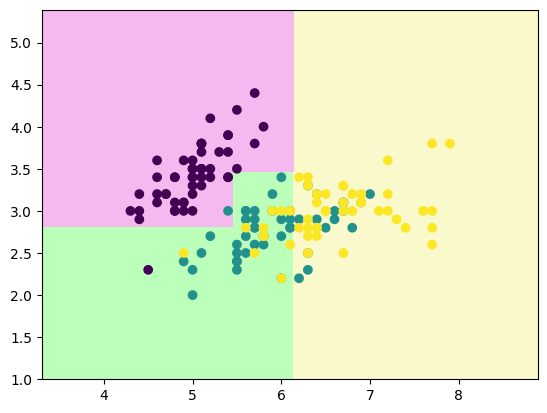

[Text(0.5, 0.875, 'x[0] <= 5.45\ngini = 0.667\nsamples = 150\nvalue = [50, 50, 50]'),
 Text(0.25, 0.625, 'x[1] <= 2.8\ngini = 0.237\nsamples = 52\nvalue = [45, 6, 1]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'gini = 0.449\nsamples = 7\nvalue = [1, 5, 1]'),
 Text(0.375, 0.375, 'gini = 0.043\nsamples = 45\nvalue = [44, 1, 0]'),
 Text(0.75, 0.625, 'x[0] <= 6.15\ngini = 0.546\nsamples = 98\nvalue = [5, 44, 49]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[1] <= 3.45\ngini = 0.508\nsamples = 43\nvalue = [5.0, 28.0, 10.0]'),
 Text(0.5, 0.125, 'gini = 0.388\nsamples = 38\nvalue = [0, 28, 10]'),
 Text(0.75, 0.125, 'gini = 0.0\nsamples = 5\nvalue = [5, 0, 0]'),
 Text(0.875, 0.375, 'gini = 0.413\nsamples = 55\nvalue = [0, 16, 39]')]

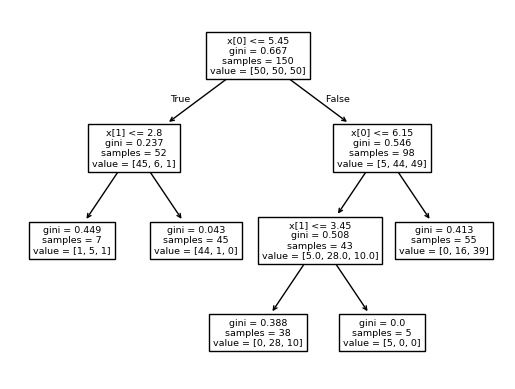

In [258]:
decision_boundary_plot(X, y, best_clf)
plot_tree(best_clf)